In [1]:
#import required libraries
import os
import pickle
import numpy as np
from tqdm.notebook import tqdm
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Dropout, add

In [11]:
# Set Directories to use images and captions
base_dir = 'D:\py_jupyter\IMAGE_CAPTION'
working_dir = 'D:\py_jupyter\IMAGE_CAPTION\Working'

Extract Image Features

In [12]:
#load vgg16 model
model = VGG16()
# restructure the model
model = Model(inputs=model.inputs, outputs=model.layers[-2].output)
# summarize
print(model.summary())

NameError: name 'VGG16' is not defined

In [13]:
# extract features from image
features = {}
directory = os.path.join(base_dir, 'Images')

for img_name in tqdm(os.listdir(directory)):
    # load the image from file
    img_path = directory + '/' + img_name
    image = load_img(img_path, target_size=(224, 224))
    # convert image pixels to numpy array
    image = img_to_array(image)
    # reshape data for model
    image = image.reshape((1, image.shape[0], image.shape[1], image.shape[2]))
    # preprocess image for vgg
    image = preprocess_input(image)
    # extract features
    feature = model.predict(image, verbose=0)
    # get image ID
    image_id = img_name.split('.')[0]
    # store feature
    features[image_id] = feature

NameError: name 'os' is not defined

In [6]:
# store features in pickle
pickle.dump(features, open(os.path.join(working_dir, 'features.pkl'), 'wb'))

In [3]:
#Load features from pickle
with open(os.path.join(working_dir, 'features.pkl'), 'rb') as f:
    features = pickle.load(f)

Load Captions of Data

In [4]:
with open(os.path.join(base_dir, 'captions.txt'), 'r') as f:
    next(f)
    captions_doc = f.read()

In [5]:
# create mapping of image to captions
mapping = {}
# process lines
for line in tqdm(captions_doc.split('\n')):
    # split the line by comma(,)
    tokens = line.split(',')
    if len(line) < 2:
        continue
    image_id, caption = tokens[0], tokens[1:]
    # remove extension from image ID
    image_id = image_id.split('.')[0]
    # convert caption list to string
    caption = " ".join(caption)
    # create list if needed
    if image_id not in mapping:
        mapping[image_id] = []
    # store the caption
    mapping[image_id].append(caption)

  0%|          | 0/40456 [00:00<?, ?it/s]

In [7]:
len(mapping)

8091

In [6]:
#We Process the Text Data
def clean(mapping):
    for key, captions in mapping.items():
        for i in range(len(captions)):
            # take one caption at a time
            caption = captions[i]
            # preprocessing steps
            # convert to lowercase
            caption = caption.lower()
            # delete digits, special chars, etc., 
            caption = caption.replace('[^A-Za-z]', '')
            # delete additional spaces
            caption = caption.replace('\s+', ' ')
            # add start and end tags to the caption
            caption = 'startseq ' + " ".join([word for word in caption.split() if len(word)>1]) + ' endseq '
            captions[i] = caption

In [7]:
# before preprocess of text
mapping['1000268201_693b08cb0e']

['A child in a pink dress is climbing up a set of stairs in an entry way .',
 'A girl going into a wooden building .',
 'A little girl climbing into a wooden playhouse .',
 'A little girl climbing the stairs to her playhouse .',
 'A little girl in a pink dress going into a wooden cabin .']

In [8]:
#preprocess the text
clean(mapping)

In [9]:
#after preprocess of text
mapping['1000268201_693b08cb0e']

['startseq child in pink dress is climbing up set of stairs in an entry way endseq ',
 'startseq girl going into wooden building endseq ',
 'startseq little girl climbing into wooden playhouse endseq ',
 'startseq little girl climbing the stairs to her playhouse endseq ',
 'startseq little girl in pink dress going into wooden cabin endseq ']

In [10]:
# store the preprocessed captions into a list
all_captions = []
for key in mapping:
    for caption in mapping[key]:
        all_captions.append(caption)

In [11]:
len(all_captions)

40455

In [12]:
all_captions[:10]

['startseq child in pink dress is climbing up set of stairs in an entry way endseq ',
 'startseq girl going into wooden building endseq ',
 'startseq little girl climbing into wooden playhouse endseq ',
 'startseq little girl climbing the stairs to her playhouse endseq ',
 'startseq little girl in pink dress going into wooden cabin endseq ',
 'startseq black dog and spotted dog are fighting endseq ',
 'startseq black dog and tri-colored dog playing with each other on the road endseq ',
 'startseq black dog and white dog with brown spots are staring at each other in the street endseq ',
 'startseq two dogs of different breeds looking at each other on the road endseq ',
 'startseq two dogs on pavement moving toward each other endseq ']

In [13]:
# tokenize the text
tokenizer = Tokenizer()
tokenizer.fit_on_texts(all_captions)
vocab_size = len(tokenizer.word_index) + 1

In [14]:
vocab_size

8485

In [15]:
# get maximum length of the caption available
max_length = max(len(caption.split()) for caption in all_captions)
max_length

35

We Split the data into train and test dataset

In [16]:
image_ids = list(mapping.keys())
split = int(len(image_ids) * 0.90)
train = image_ids[:split]
test = image_ids[split:]

In [17]:
# startseq girl going into wooden building endseq
#        X                   y
# startseq                   girl
# startseq girl              going
# startseq girl going        into
# ...........
# startseq girl going into wooden building      endseq

In [18]:
# create data generator to get data in batch (avoids session crash)
def data_generator(data_keys, mapping, features, tokenizer, max_length, vocab_size, batch_size):
    # loop over images
    X1, X2, y = list(), list(), list()
    n = 0
    while 1:
        for key in data_keys:
            n += 1
            captions = mapping[key]
            # process each caption
            for caption in captions:
                # encode the sequence
                seq = tokenizer.texts_to_sequences([caption])[0]
                # split the sequence into X, y pairs
                for i in range(1, len(seq)):
                    # split into input and output pairs
                    in_seq, out_seq = seq[:i], seq[i]
                    # pad input sequence
                    in_seq = pad_sequences([in_seq], maxlen=max_length)[0]
                    # encode output sequence
                    out_seq = to_categorical([out_seq], 	num_classes=vocab_size)[0]
                    # store the sequences
                    X1.append(features[key][0])
                    X2.append(in_seq)
                    y.append(out_seq)
            if n == batch_size:
                X1, X2, y = np.array(X1), np.array(X2), np.array(y)
                yield {"image": X1, "text": X2}, y
                X1, X2, y = list(), list(), list()
                n = 0

In [44]:
!pip install pydot

In [21]:
!pip install pydot graphviz

   ---------------------------------------- 0.0/47.1 kB ? eta -:--:--
   ---------------------------------------- 47.1/47.1 kB 1.2 MB/s eta 0:00:00


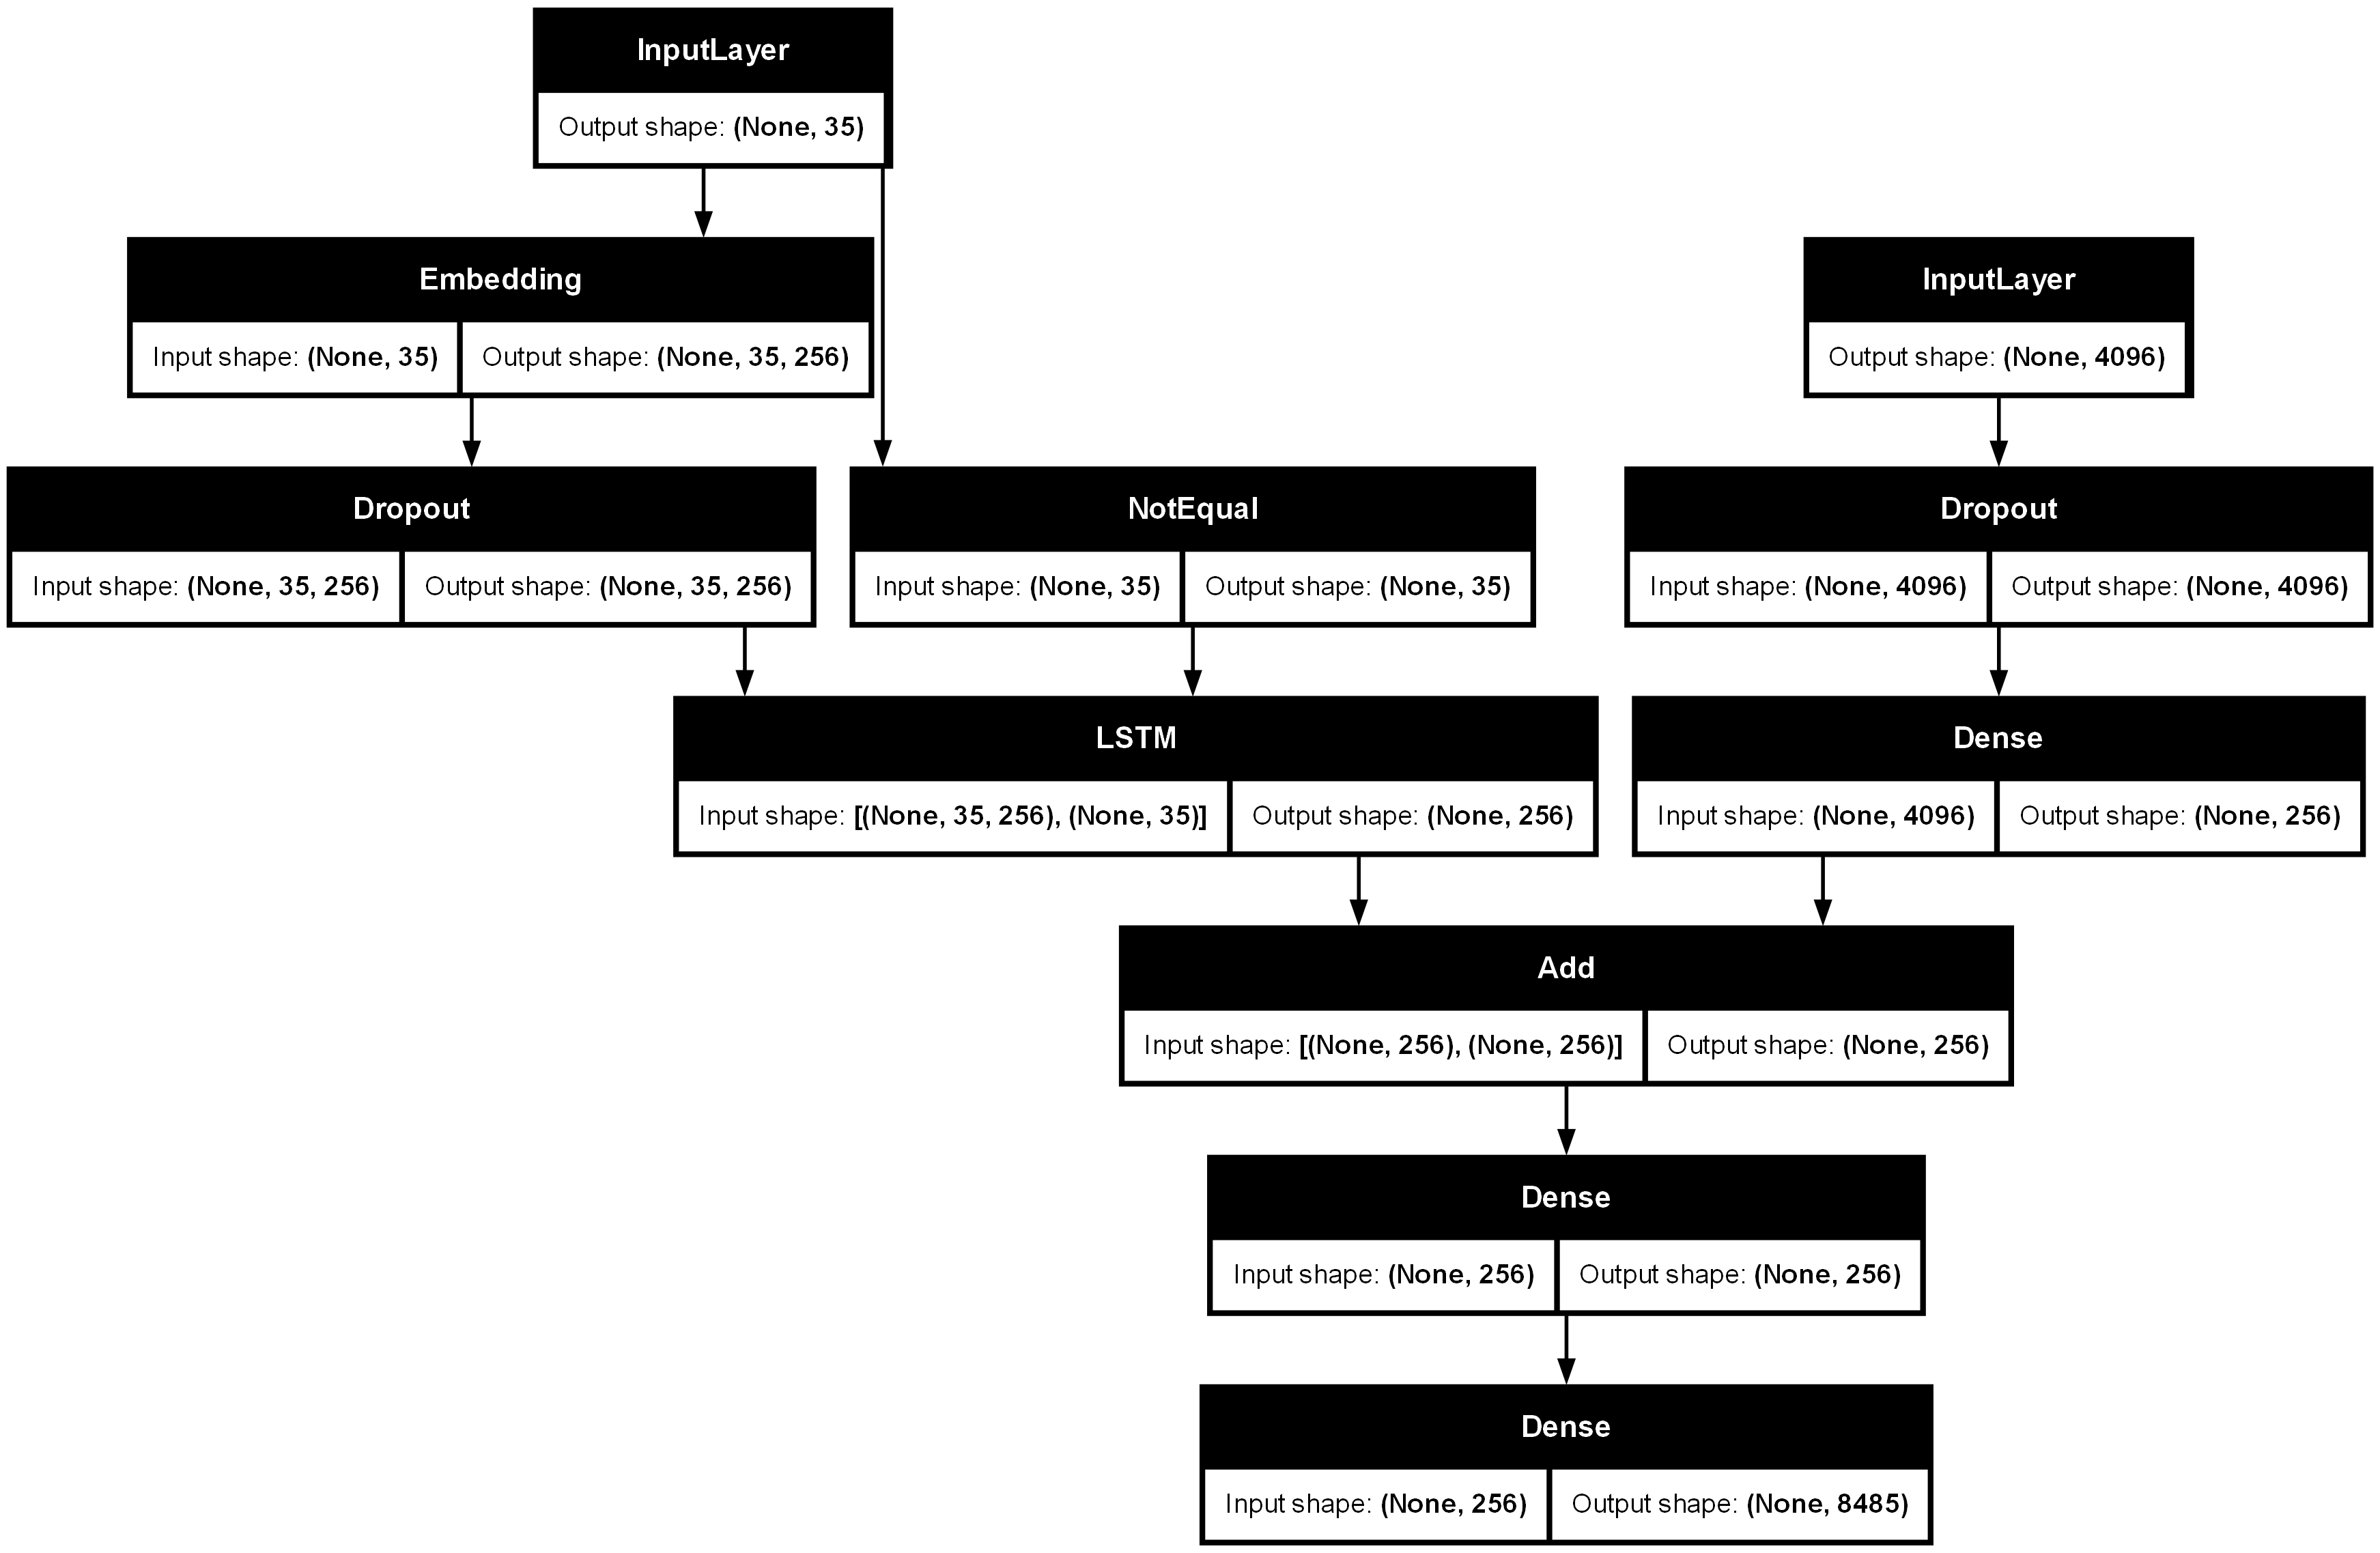

In [19]:
#Model
# encoder model
# image feature layers
inputs1 = Input(shape=(4096,), name="image")
fe1 = Dropout(0.4)(inputs1)
fe2 = Dense(256, activation='relu')(fe1)
# sequence feature layers
inputs2 = Input(shape=(max_length,), name="text")
se1 = Embedding(vocab_size, 256, mask_zero=True)(inputs2)
se2 = Dropout(0.4)(se1)
se3 = LSTM(256)(se2)

# decoder model
decoder1 = add([fe2, se3])
decoder2 = Dense(256, activation='relu')(decoder1)
outputs = Dense(vocab_size, activation='softmax')(decoder2)

model = Model(inputs=[inputs1, inputs2], outputs=outputs)
model.compile(loss='categorical_crossentropy', optimizer='adam')

# plot the model
plot_model(model, show_shapes=True)

In [22]:
# train the model
epochs = 20
batch_size = 32
steps = len(train) // batch_size

for i in range(epochs):
    # create data generator
    generator = data_generator(train, mapping, features, tokenizer, max_length, vocab_size, batch_size)
    # fit for one epoch
    model.fit(generator, epochs=1, steps_per_epoch=steps, verbose=1)

227/227 ━━━━━━━━━━━━━━━━━━━━ 664s 3s/step - loss: 5.7831
227/227 ━━━━━━━━━━━━━━━━━━━━ 651s 3s/step - loss: 4.0936
227/227 ━━━━━━━━━━━━━━━━━━━━ 645s 3s/step - loss: 3.6140
227/227 ━━━━━━━━━━━━━━━━━━━━ 653s 3s/step - loss: 3.3251
227/227 ━━━━━━━━━━━━━━━━━━━━ 649s 3s/step - loss: 3.1123
227/227 ━━━━━━━━━━━━━━━━━━━━ 645s 3s/step - loss: 2.9499
227/227 ━━━━━━━━━━━━━━━━━━━━ 648s 3s/step - loss: 2.8337
227/227 ━━━━━━━━━━━━━━━━━━━━ 554s 2s/step - loss: 2.7413
227/227 ━━━━━━━━━━━━━━━━━━━━ 546s 2s/step - loss: 2.6637
227/227 ━━━━━━━━━━━━━━━━━━━━ 545s 2s/step - loss: 2.5952
227/227 ━━━━━━━━━━━━━━━━━━━━ 551s 2s/step - loss: 2.5350
227/227 ━━━━━━━━━━━━━━━━━━━━ 553s 2s/step - loss: 2.4846
227/227 ━━━━━━━━━━━━━━━━━━━━ 556s 2s/step - loss: 2.4318
227/227 ━━━━━━━━━━━━━━━━━━━━ 553s 2s/step - loss: 2.3839
227/227 ━━━━━━━━━━━━━━━━━━━━ 552s 2s/step - loss: 2.3430
227/227 ━━━━━━━━━━━━━━━━━━━━ 550s 2s/step - loss: 2.3036
227/227 ━━━━━━━━━━━━━━━━━━━━ 549s 2s/step - loss: 2.2659
227/227 ━━━━━━━━━━━━━━━━━━━━ 55

In [24]:
# save the model
model.save(working_dir+'/best_model.keras')

In [26]:
model.save(working_dir+'/a_model.h5')

In [20]:
from keras.models import load_model
#we load the our model
model = load_model(working_dir+"/best_model.keras")
#model = load_model(working_dir+"/a_model.h5")

C:\Users\susha\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\saving\saving_lib.py:415: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 12 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Generate Captions for the Image

In [21]:
def idx_to_word(integer, tokenizer):
    for word, index in tokenizer.word_index.items():
        if index == integer:
            return word
    return None

In [22]:
# generate caption for an image
def predict_caption(model, image, tokenizer, max_length):
    # add start tag for generation process
    in_text = 'startseq'
    # iterate over the max length of sequence
    for i in range(max_length):
        # encode input sequence
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        # pad the sequence
        sequence = pad_sequences([sequence], max_length)
        # predict next word
        yhat = model.predict([image, sequence], verbose=0)
        # get index with high probability
        yhat = np.argmax(yhat)
        # convert index to word
        word = idx_to_word(yhat, tokenizer)
        # stop if word not found
        if word is None:
            break
        # append word as input for generating next word
        in_text += " " + word
        # stop if we reach end tag
        if word == 'endseq':
            break
    return in_text

In [36]:
!pip install nltk

     ---------------------------------------- 0.0/42.0 kB ? eta -:--:--
     ------------------ ------------------- 20.5/42.0 kB 640.0 kB/s eta 0:00:01
     -------------------------------------- 42.0/42.0 kB 511.8 kB/s eta 0:00:00
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   - -------------------------------------- 0.1/1.5 MB 1.7 MB/s eta 0:00:01
   ---- ----------------------------------- 0.2/1.5 MB 1.7 MB/s eta 0:00:01
   ----- ---------------------------------- 0.2/1.5 MB 1.8 MB/s eta 0:00:01
   ------------ --------------------------- 0.5/1.5 MB 2.6 MB/s eta 0:00:01
   --------------- ------------------------ 0.6/1.5 MB 2.6 MB/s eta 0:00:01
   ------------------------- -------------- 1.0/1.5 MB 3.6 MB/s eta 0:00:01
   --------------------------------- ------ 1.3/1.5 MB 4.0 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 4.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/269.0 kB ? eta -:--:--
   -----------------

validate the data using BLEU Score

In [25]:
from nltk.translate.bleu_score import corpus_bleu
# validate with test data
actual, predicted = list(), list()

for key in tqdm(test):
    # get actual caption
    captions = mapping[key]
    # predict the caption for image
    y_pred = predict_caption(model, features[key], tokenizer, max_length)
    # split into words
    actual_captions = [caption.split() for caption in captions]
    y_pred = y_pred.split()
    # append to the list
    actual.append(actual_captions)
    predicted.append(y_pred)
    
# calcuate BLEU score
print("BLEU-1: %f" % corpus_bleu(actual, predicted, weights=(1.0, 0, 0, 0)))
print("BLEU-2: %f" % corpus_bleu(actual, predicted, weights=(0.5, 0.5, 0, 0)))

  0%|          | 0/810 [00:00<?, ?it/s]

BLEU-1: 0.534786
BLEU-2: 0.307635


In [38]:
# Visualize the output
from PIL import Image
import matplotlib.pyplot as plt
def generate_real_caption(image_name):
    #Set path
    img_real_dir = "D:\py_jupyter\ImgCap"
    # get image ID
    image_id = image_name.split('.')[0]
    #Jion the path
    img_path = os.path.join(img_real_dir, image_name)
    

    image = load_img(img_path, target_size=(224, 224))
    # convert image pixels to numpy array
    image = img_to_array(image)
    # reshape data for model
    image = image.reshape((1, image.shape[0], image.shape[1], image.shape[2]))
    # preprocess image for vgg
    image = preprocess_input(image)
    # extract features
    feature = model.predict(image, verbose=0)
    # store feature
    features[image_id] = feature

    #open image
    image = Image.open(image_name)
    
    # predict the caption
    y_pred = predict_caption(model, features[image_id], tokenizer, max_length)
    print('--------------------Predicted--------------------')
    print(y_pred)
    plt.imshow(image)

In [33]:
from PIL import Image
import matplotlib.pyplot as plt
def generate_caption(image_name):
    # load the image
    # image_name = "1001773457_577c3a7d70.jpg"
    image_id = image_name.split('.')[0]
    img_path = os.path.join(base_dir, "Images", image_name)
    image = Image.open(img_path)
    captions = mapping[image_id]
    print('---------------------Actual---------------------')
    for caption in captions:
        print(caption)
    # predict the caption
    y_pred = predict_caption(model, features[image_id], tokenizer, max_length)
    print('--------------------Predicted--------------------')
    print(y_pred)
    plt.imshow(image)

Generate Some Captions

---------------------Actual---------------------
startseq children sit and watch the fish moving in the pond endseq 
startseq people stare at the orange fish endseq 
startseq several people are standing near fish pond endseq 
startseq some children watching fish in pool endseq 
startseq there are several people and children looking into water with blue tiled floor and goldfish endseq 
--------------------Predicted--------------------
startseq four children are playing in an outdoor place endseq


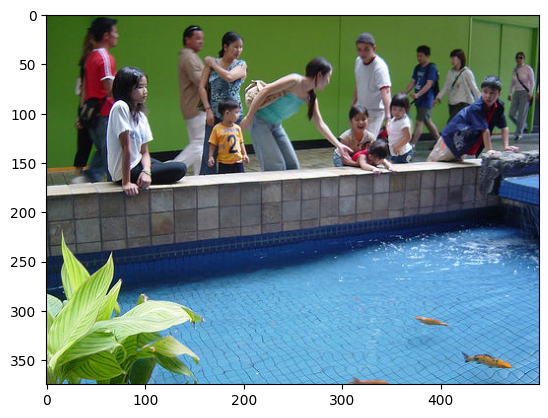

In [34]:
generate_caption("12830823_87d2654e31.jpg")

---------------------Actual---------------------
startseq couple watches boat against skyline endseq 
startseq "a man and woman sit on bench watching boat go by ." endseq 
startseq the sun is setting while man and woman watch boat go by endseq 
startseq two people sit on bench and watch boat on the water endseq 
startseq two people watching boat sail past endseq 
--------------------Predicted--------------------
startseq two people are standing in the snow looking out at the end of the ocean endseq


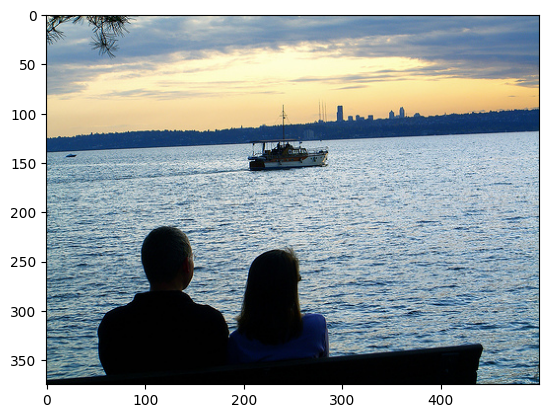

In [42]:
generate_caption("44129946_9eeb385d77.jpg")

In [39]:
generate_real_caption("1.jpeg")

ValueError: Layer 'functional_3' expected 2 input(s). Received 1 instead.

---------------------Actual---------------------
startseq two brown dogs fight over some cloth endseq 
startseq two dogs are fighting over plastic bag endseq 
startseq two dogs fight over bag on wooden deck endseq 
startseq two golden dogs are chewing white cushion on wooden patio endseq 
startseq two medium sized light brown dogs are playing tug of war with dish cloth endseq 
--------------------Predicted--------------------
startseq two dogs are playing tug of war on the grass endseq


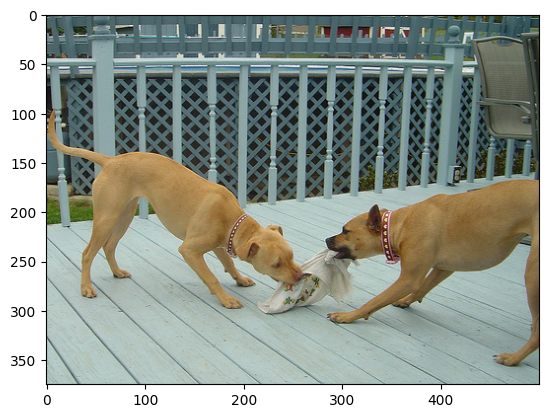

In [43]:
generate_caption("244867897_d00369a779.jpg")

---------------------Actual---------------------
startseq big brown dog swims towards the camera endseq 
startseq brown dog treads through water endseq 
startseq closeup image of dog swimming endseq 
startseq the furry brown dog is swimming in the ocean endseq 
startseq wet brown dog swims towards camera endseq 
--------------------Predicted--------------------
startseq dog swims with stick in its mouth endseq


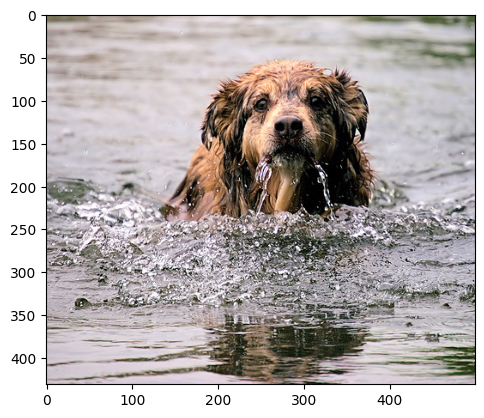

In [44]:
generate_caption("262642489_f5c6b9e65b.jpg")

---------------------Actual---------------------
startseq climber is standing on rocks overlooking snowy mountain range endseq 
startseq lone climber on snowy moutainside endseq 
startseq man in white helmet and dark clothing stands in the snowy mountains endseq 
startseq "a man is overlooking big snowy mountain ." endseq 
startseq man with white helmet stands on snowy mountaintop endseq 
--------------------Predicted--------------------
startseq man in red coat and backpack stands on snow covered mountain endseq


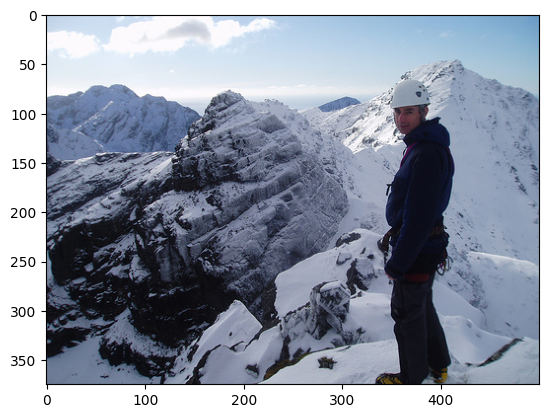

In [47]:
generate_caption("262963190_a78b799e89.jpg")

<Thank You>

<Thank You>

Thank You